# **⛑️ Safety Helmet Detection with YOLOv8**
In this lab, we will:
✅ **Use YOLOv26** for **safety helmet detection** in petrochemical environments  
✅ **Understand the dataset structure**  
✅ **Train a YOLOv26 model**  
✅ **Evaluate the model on the validation set**  
✅ **Run inference on test images**  

---

## **1️⃣ Understanding the Dataset Structure**
The dataset follows the **YOLO format**, which consists of:
📂 **train/** → Training images & labels  
📂 **valid/** → Validation images & labels  
📂 **test/** → Test images (for inference)  
📜 **data.yaml** → Defines dataset paths & class names  

We will use the **Construction-PPE** dataset from Ultralytics, which includes:
- Helmets, vests, gloves, boots, goggles
- **Missing equipment** classes (no_helmet, no_vest, etc.)

### https://docs.ultralytics.com/datasets/detect/construction-ppe

## **2️⃣ What's Inside a YOLO Label File?**
Each `.txt` file contains **annotations** in this format:

class_id | x_center | y_center | width height

✅ **All values are normalized** between **0 and 1**  
✅ The **bounding box** is defined by its **center** and **size**  

### **🔹 Example**
0 0.526 0.448 0.12 0.15
3 0.731 0.602 0.18 0.22

- **First column** → Class ID (`0` = boots, `3` = helmet, etc.)  
- **Rest** → Bounding box (normalized)

## **3️⃣ Loading the Dataset**

In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset
import matplotlib.pyplot as plt

# Download the Construction-PPE dataset
dataset_info = check_det_dataset("construction-ppe.yaml")
dataset_path = "construction-ppe.yaml"

print("Classes:", dataset_info["names"])

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

WARNING ⚠️ Dataset 'construction-ppe.yaml' images not found, missing path '/content/datasets/construction-ppe/images/val'
Unzipping /content/datasets/construction-ppe.zip to /content/datasets/construction-ppe...: 100% ━━━━━━━━━━━━ 2852/2852 855.3files/s 3.3s
Dataset download success ✅ (5.2s), saved to /content/datasets

Classes: {0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles', 5: 'none', 6: 'Person', 7: 'no_helmet', 8: 'no_goggle', 9: 'no_gloves', 10: 'no_boots'}


In [ ]:
# Check dataset information
from pathlib import Path

ds_root = Path(dataset_info["path"])
train_images = list((ds_root / "images" / "train").glob("*"))
val_images = list((ds_root / "images" / "val").glob("*"))
test_images = list((ds_root / "images" / "test").glob("*"))

print(f"Train images: {len(train_images)}")
print(f"Val images:   {len(val_images)}")
print(f"Test images:  {len(test_images)}")

Train images: 1132
Val images:   143
Test images:  141


## **4️⃣ Training a YOLOv8 Model**
We will fine-tune a **pretrained YOLOv8 model**.

In [ ]:
# Load YOLOv26 model (small version)
model = YOLO("yolo26n.pt")


image 1/1 /content/datasets/construction-ppe/images/test/image287.jpg: 640x640 1 person, 15.9ms
Speed: 8.1ms preprocess, 15.9ms inference, 47.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


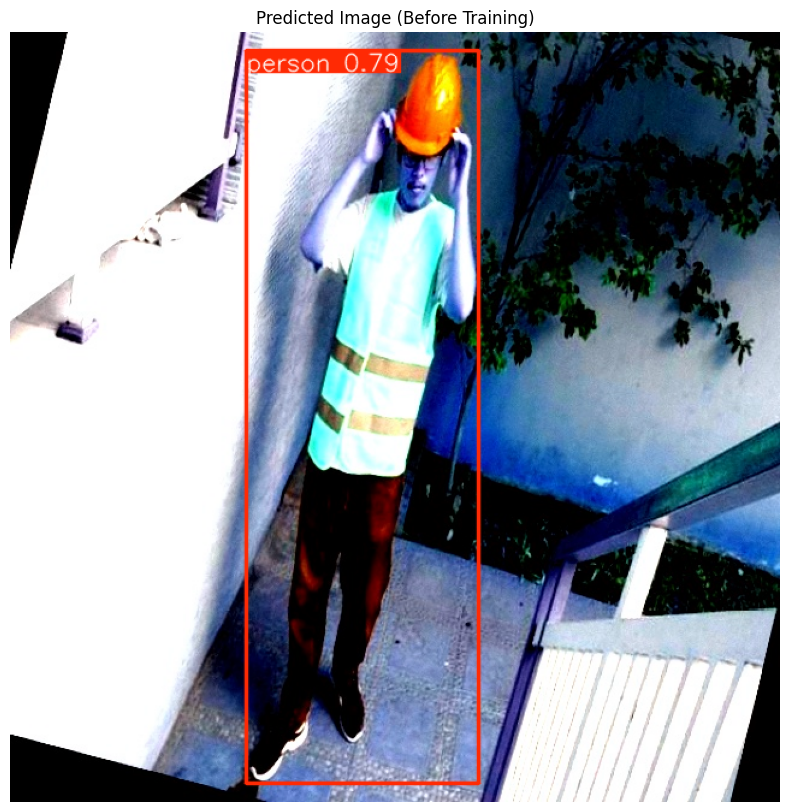

In [ ]:
# Run inference BEFORE training
results = model(str(test_images[1]), save=True)


predicted_image = results[0].plot()

plt.figure(figsize=(10, 10))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image (Before Training)")
plt.show()

#### The model doesn't thinks humans are horses... Let's try to train it! 🚀

In [ ]:
# Train on the Construction-PPE dataset
model.train(data=dataset_path, epochs=20, imgsz=640)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=construction-ppe.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78cacb324200>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

## **5️⃣ Evaluating the Model**
We use **mAP@0.5:0.95** to assess performance.

In [ ]:
# Run validation
metrics = model.val(data=dataset_path)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2259.8±1396.6 MB/s, size: 132.2 KB)
val: Scanning /content/datasets/construction-ppe/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 66.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.3it/s 3.9s
                   all        143       1172      0.725      0.352      0.385      0.191
                helmet        107        201      0.564      0.682      0.653      0.336
                gloves         68        136      0.473      0.515      0.529      0.253
                  vest        109        171      0.592      0.713      0.672      0.374
                 boots         64        151      0.551      0.616      0.604      0.339
               goggles         44         47      0.695      0.277      0.429       0.22
                  none  

## **6️⃣ Running Inference on Test Images**


image 1/1 /content/datasets/construction-ppe/images/test/image287.jpg: 640x640 2 helmets, 2 vests, 1 boots, 1 Person, 9.5ms
Speed: 2.6ms preprocess, 9.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


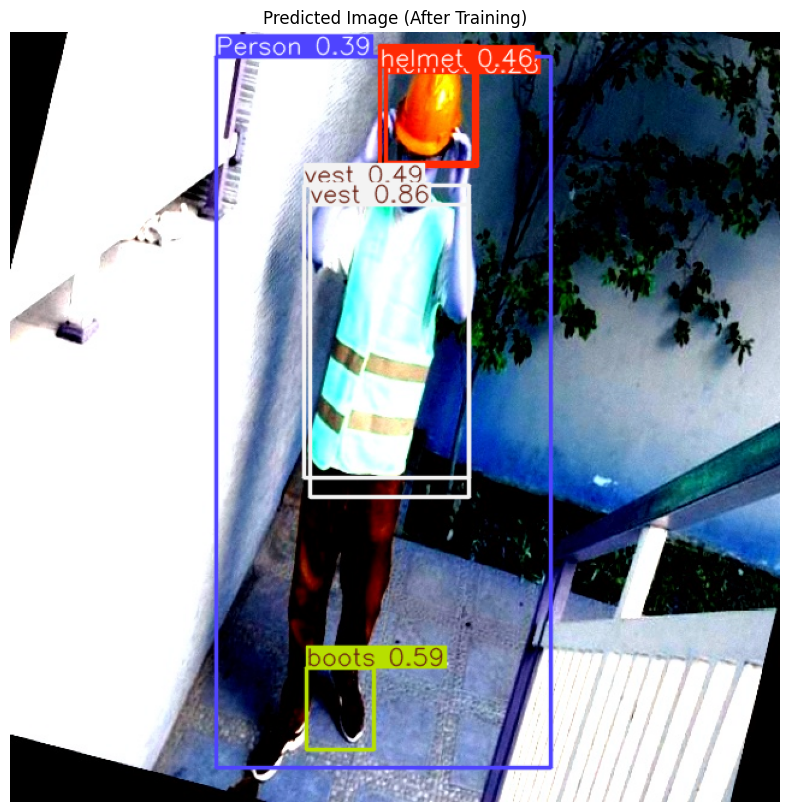

In [ ]:
# Load best weights and run inference
model = YOLO(model.trainer.best)
results = model(str(test_images[1]), save=True)

predicted_image = results[0].plot()

plt.figure(figsize=(10, 10))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image (After Training)")
plt.show()

### 🚀 **Now you have a working YOLOv8 object detection pipeline for safety helmets!**

###Contributed by: Yazan Alshoibi